In [212]:
from __future__ import annotations
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send
from typing import TypedDict,Annotated,List,Optional,Literal
from pydantic import BaseModel,Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage,HumanMessage
from langchain_community.tools import TavilySearchResults
from datetime import date,timedelta
import os
from pathlib import Path
import operator
import re
from huggingface_hub import InferenceClient
from dotenv import load_dotenv
load_dotenv()

True

In [213]:
class Task(BaseModel):
    id : int
    title : str
    goal : str = Field(...,description="one sentence describing what the reader should be able to do/understand after this section.")
    bullets : List[str] = Field(...,min_length=3,max_length=5,description="3-5 concrete,non-overlapping subpoints to cover in this section.")
    tags : List[str] = Field(default_factory=list)
    target_words : int = Field(...,description="Target word count for this section (120-450).")
    section_type : int = Field(...,description="use 'common-mistakes' exactl once in this plan")
    requires_research : bool = False
    requires_citations : bool = False
    requires_code : bool = False

In [214]:
class Plan(BaseModel):
    blog_title : str
    audience : str = Field(...,description="who the blog is for")
    tone : str
    blog_kind : Literal["explainer","tutorial","news_roundup", "comparison" , "system_design" ] =  "explainer"
    constraints : List[str] = Field(default_factory=list)
    tasks : List[Task]

In [215]:
class EvidenceItem(BaseModel): 
    title : str
    url : str
    published_at : Optional[str] = None # Keep if tavily provides: do not rely on it
    snippet : Optional[str] = None
    source : Optional[str] = None

In [216]:
class RouterDecision(BaseModel):
    needs_research : bool
    mode : Literal["closed_book","hybrid","open_book"]
    queries : List[str] = Field(default_factory=list)

In [217]:
class EvidencePack(BaseModel):
    evidence : List[EvidenceItem] = Field(default_factory=list)

In [218]:
class AgentState(TypedDict):
    topic : str
    mode : str
    as_of : str
    recenty_days : int
    needs_research : bool
    queries : List[str]
    evidence : List[EvidenceItem]
    plan : Plan # worker's
    sections : Annotated[List[tuple[int,str]],operator.add] # [task-id,section-md]
    merged_md : str
    md_with_placeholders:str
    image_specs : List[dict]
    final : str

In [219]:
llm = ChatGoogleGenerativeAI(model='gemini-3.5-flash-lite')

In [220]:
ROUTER_SYSTEM = """ You are a routing module for a technical blog planner.
Decide whether web reasearch is needed before planner.
Modes:
- closed_book(needs_research = false):
Evergreen topics where correctness does not depend on recent facts(concepts,fundamentals).
- hybrid (needs_research = true):
- open_book (needs_research = true):
Mostly volatile : weekly roundups , "the week","latest", rankings, pricing, policy/regulation.
If needs_research = true:
- output 3-10 high-signal queries.
- queries should be scoped & specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week / this week / latest",reflect that constraint in the queries."""

In [221]:
def router_node(state:AgentState)->dict:
    topic = state['topic']
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke([
        SystemMessage(content=ROUTER_SYSTEM),
        HumanMessage(content=f"Topic : {topic}")
    ])
    return {
        "needs_research" : decision.needs_research,
        "mode" : decision.mode,
        "queries" : decision.queries
    }

In [222]:
def route_next(state:AgentState)->str:
    return "research" if state['needs_research'] else "orchestrator"

In [223]:
def _tavily_search(query:str,max_results:int=5)->List[dict]:
    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query":query})
    normalized : List[dict] = []
    for r in results or []:
        normalized.append(
            {
                "title" : r.get("title") or "",
                "url" : r.get("url") or "",
                "snippet" : r.get("content") or r.get("snippet") or "",
                "published_at" : r.get("published_date") or r.get("published_at"),
                "source" : r.get("source")
            }
        )
    return normalized

In [224]:
RESEARCH_SYSTEM = """ you are a research synthesizer for techinal writing.
Given raw web search , produce a deduplicated list of EvidenceItem Objects.
Rules : 
- Only inlcude items with a non-emtpy url.
- prefer relevaant and authoritative sources (company blogs,docs,reputable outlets).
- If a published is explicitly present in the results payload , keep it as YYYY-MM_DD.
If missing or unclear, set published_at = null. DO NOT GUESS.
- Keep snippets short.
- deduplicate the URL."""

In [225]:
def research_node(state:AgentState) -> dict:
    # take the first 10 queries from the state
    queries = (state.get('queries',[]) or [])
    max_results = 5
    raw_results : List[dict] = []
    for q in queries : 
        raw_results.extend(_tavily_search(q,max_results=max_results))
    if not raw_results:
        return {"evidence":[]}
    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content=f"Raw results: \n{raw_results}")
        ]
    )
    # Deduplicate by url
    dedup = {}
    for e in pack.evidence:
        if e.url : 
            dedup[e.url] = e
    return {"evidence":list(dedup.values())}

In [226]:
ORCH_SYSTEM = """You are a Senior technial writer and developer advocate. you job is to produce a highly actionable outline for a technical blog post.\n\n"
            
            Hard requirements:
            - Create 5-7 sections (tasks) suitable for the topic and audience
            - Each task must include:
                1) goal (1 sentence).
                2) 3-5 bullets that are concrete,specific and non-overlapping.
                3) target word count(120-450).
            
            Quality bar : 
            - Assume the reader is a developer; use correct terminology.
            - Bullets must be actionable; build/compare/measure/verify/debug. 
            - Ensure that overall plan includes at least 2 of these somewhere:
                * minimal code sketch / MWE (set requires_code=True for that section)
                * edge cases / feature modes
                * performace / cost consideration
                * security/privacy consideration (if relevant)
                * debugging / observability tips
            - Avoid Valgure bullets like 'Explain X' or 'Discuss Y'. Every bullet should state what to build/compare/measure .
            
            Grounding rules:
            - Mode close_book : keep it evergreen; do not depend on evidence.
            - Mode hybrid : 
                - Use evidence for up-to-date examples (models/tools/releases) in bullets.
                - Mark sections using fresh info as requires_research = True and requires_citations= True.
            - Mode open_book:
                - Set blog_kind = "news_roundup"
                - Every sections is about summarizing events + implications.
                - do not include tutorial/how-to sections unless user explicitily asked for that.
                - If evidence is empty or insufficient, create a plan that transaparently says "insufficient sources" and includes only what can be supported.
            
            output must strictly match the Plan schema
            """

In [227]:
def orchestrator(state:AgentState)->AgentState:
    evidence = state.get("evidence",[])
    mode = state.get("mode","closed_book")
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(content=(
                         f'Topic:{state['topic']}\n'
                         f'Mode :{mode}'
                         f'Evidence (only use for fresh claims; may be empty):\n'
                         f' {[e.model_dump() for e in evidence][:16]}'
                        )
            )
        ]
    )
    return {'plan':plan}

In [228]:
def fanout(state:AgentState):
    return [
        Send(
            "worker",
            {
            "task": task.model_dump(),
            "topic": state['topic'],
            "mode" : state["mode"],
            "plan": state['plan'].model_dump(),
            "evidence" : [e.model_dump() for e in state.get("evidence",[])]
            }
            ) 
            for task in state['plan'].tasks
    ]

In [229]:
WORKER_SYSTEM = """"You are a senior techinal writer and developer advocate. 
write one section of a technical blog post in markdown."
        "Hard Constraints : \n"
        "- Follow the provided goal and cover all bullets in order (donot skip or merge bullets).\n"
        "- stay close to the target words(+-15%).\n"
        "- output only the section content in Markdown (no blog title H1 , no extra commentory)\n\n"
        "- Start with a '##<Section Title>' heading.\n"
        
        Scope guard:
        - If blog_kind == "news_roundup": do not turn this into a tutorial/how-to guide.
          do not teach web scraping , RSS , automation , or "how to fetch news" unless bullets explicity aks for it
        
        Grounding policy:
        - If mode == open_book:
           - do not introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URL
           - For each event claim , attach a source as a Markdown link: ([Source](URL)).
           - only use URLs provided in Evidence. If not supported, write : "Not found in provided sources"
        - If requires_citations == true:
           - For outside-world claims,cite Evidence URLs the same way.
        - Evergreen reasoning is OK without citationss unless requires_citations as true.
        
        Code:
           - If requires_code = true , include at least one minimal, correct code snippet relevant to the bullets.
        
        Style:
           - short paragraphs , bullets where helpful , code fences for code.
           - Avoid fluff/marketing. Be precise and implementation-oriented.


"""

In [230]:
def worker(payload:dict)->dict:
    task = Task(**payload['task'])
    topic = payload['topic']
    plan = Plan(**payload['plan'])
    mode = payload.get("mode","closed_book")
    evidence = [EvidenceItem(**e) for e in payload.get("evidence",[])]
    bullets_text = "\n- " + "\n- ".join(task.bullets)
    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )
    section_md = llm.invoke([
        SystemMessage(content=WORKER_SYSTEM),
        HumanMessage(
            content=f"Blog title: {plan.blog_title}\n"
            f"Audience: {plan.audience}"
            f"Tone : {plan.tone}\n"
            f"Blog kind : {plan.blog_kind}"
            f"Constraints : {plan.constraints}\n"
            f"Topic: {topic}\n\n"
            f"Mode: {mode}\n\n"
            f"Section title: {task.title}\n"
            f"Goal : {task.goal}"
            f"Target words: {task.target_words}\n"
            f"Tags : {task.tags}\n"
            f"requires_research : {task.requires_research}\n"
            f"requires_citations : {task.requires_citations}\n"
            f"requires_code : {task.requires_code}\n"
            f"Bullets: {bullets_text}\n"
            f"Evidence (Only use these URLs when citing):\n{evidence_text}"
        )
    ]).content[0]['text'].strip()
    return {"sections":[(task.id,section_md)]}


In [231]:
class ImageSpec(BaseModel):
    placeholder : str = Field(...,description="e.g.,[[IMAGE_1]]")
    filename : str = Field(...,description="save under images/, e.g, qwern_flow.png")
    alt : str
    caption : str
    prompt : str = Field(...,description="prompt to send to the image model.")
    size : Literal["1024x1024","1024x1536","1536x1024"] = "1024x1024"
    quality : Literal["low","medium","high"] = "medium"

In [232]:
class GlobalImagePlan(BaseModel):
    md_with_placeholders : str
    images : List[ImageSpec] = Field(default_factory=list)

In [233]:
def merge_content(state:AgentState)->dict:
    plan = state['plan']
    ordered_sections = [md for _,md in sorted(state["sections"],key=lambda x : x[0])]
    body = "\n\n".join(ordered_sections).strip()
    merged_md = f'# {plan.blog_title}\n\n{body}\n'
    return {"merged_md":merged_md}

In [234]:
DECIDE_IMAGE_SYSTEMS = """you are an expect technical editor.
decide if images/diagrams are needed for the md

Rules : 
- Max 2 images total
- Each image must materially imrove understanding (diagram/flow/table - like visual)
- Insert placeholder exactly : [[IMAGE_1]] [[IMAGE_2]] [[IMAGE_3]].
- If no images needed : md_with_placeholder must equal input and images = []
- Avoid decorative images, prefer technial diagrams with short labels.
Return striclty GlobalImagePlan"""

In [235]:
def decider_image(state:AgentState) -> dict:
    planner = llm.with_structured_output(GlobalImagePlan)
    merged_md = state['merged_md']
    plan = state['plan']
    assert plan is not None
    image_plan = planner.invoke([
        SystemMessage(content=DECIDE_IMAGE_SYSTEMS),
        HumanMessage(content=(
            f"Blog Kind : {plan.blog_kind}"
            f"Topic : {state['topic']}\n\n"
            "Insert placeholders + Proper image promt.\n\n"
            f"{{merged_md}}"
        ))
    ])
    return {
        "md_with_placeholders" : image_plan.md_with_placeholders,
        "image_specs" : [img.model_dump() for img in image_plan.images]
    }

In [236]:
# def _gemini_generate_image_bytes(prompt:str)-> bytes:
#     """
#     Returns raw image bytes generated by Gemini.
#     Requires : pip install google_genai
#     Env var : GOOGLE_API_KEY"""
#     from google import genai
#     from google.genai import types
#     api_key = os.environ.get("GOOGLE_API_KEY")
#     if not api_key:
#         raise RuntimeError("GOOGLE_API_KEY IS NOT SET")
#     client = genai.Client(api_key=api_key)
#     resp = client.models.generate_content(
#         model = "gemini-3.1-flash-lite-image",
#         contents = prompt,
#         config = types.GenerateContentConfig(
#             response_modalities = ["IMAGE"],
#             safety_settings=[
#                 types.SafetySetting(
#                     category=types.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
#                     threshold = types.HarmBlockThreshold.BLOCK_ONLY_HIGH
#                 )
#             ]
#         )
#     )
#     # Depending on SDK version , parts may hangoff resp.candidates[0].content.parts
#     parts = getattr(resp,"parts",None)
#     if not parts and getattr(resp,"candidates",None):
#         try:
#             parts = resp.candidates[0].content.parts
#         except Exception:
#             parts = None
#     if not parts:
#         raise RuntimeError("No image content returned (safety/quota/SDK-change)")
#     for part in parts:
#         inline = getattr(part,"inline_data",None)
#         if inline and getattr(inline,"data",None):
#             return inline.data
#         raise RuntimeError("No inline image bytes found in response")

In [237]:
# prompt = """
# Create a simple technical architecture diagram showing:
# Prompt -> LLM -> Tool -> Output.
# Clean professional software engineering style.
# """

# img_bytes = _gemini_generate_image_bytes(prompt)

# print("Image generated successfully")
# print("Bytes:", len(img_bytes))

# Path("test_image.png").write_bytes(img_bytes)

# print("Saved to test_image.png")

In [238]:
def _gemini_generate_image_bytes(prompt: str) -> bytes:
    """
    Returns raw PNG image bytes generated through Hugging Face.

    Requires:
        pip install huggingface_hub

    Env var:
        HF_TOKEN
    """

    from io import BytesIO

    hf_token = os.environ.get("HF_TOKEN")

    if not hf_token:
        raise RuntimeError("HF_TOKEN IS NOT SET")

    client = InferenceClient(
        provider="auto",
        api_key=hf_token,
    )

    image = client.text_to_image(
        prompt=prompt,
        model="black-forest-labs/FLUX.1-dev",
    )

    buffer = BytesIO()
    image.save(buffer, format="PNG")

    return buffer.getvalue()

In [ ]:
def generate_and_place_images(state:AgentState)->dict:
    plan = state['plan']
    assert plan is not None
    md = state.get("md_with_placeholders") or state["merged_md"]
    images_specs = state.get("image_specs",[]) or []
    # If no images requested just write merged markdown
    if not images_specs:
        filename = re.sub(r'[^a-zA-Z0-9\s-]', '', plan.blog_title)
        filename = re.sub(r'\s+', '_', filename).strip('_').lower()[:100] + ".md"
        Path(filename).write_text(md,encoding="utf-8")
        return {"final":md}
    images_dir = Path("images")
    images_dir.mkdir(exist_ok=True)
    for spec in images_specs:
        placeholder = spec["placeholder"]
        filename = spec["filename"]
        out_path = images_dir/filename
        # generate only if needed
        if not out_path.exists():
            try:
                img_bytes = _gemini_generate_image_bytes(spec["prompt"])
                out_path.write_bytes(img_bytes)
            except Exception as e:
                prompt_block = (
                    f">**[IMAGE GENERATION FAILED]:**{spec.get('caption','')}\n>\n"
                    f">**Alt:** {spec.get('alt','')}\n>\n"
                    f">**prompt:**{spec.get('prompt','')}\n>\n"
                    f">**Error:**{e}\n>\n"
                )
                md = md.replace(placeholder,prompt_block)
                continue
        img_md = f"![{spec['alt']}](images/{filename})\n\n *{spec['caption']}*"
        md = md.replace(placeholder,img_md)
    filename = re.sub(r'[^a-zA-Z0-9\s-]', '', plan.blog_title)
    filename = re.sub(r'\s+', '_', filename).strip('_').lower()[:100] + ".md"
    Path(filename).write_text(md,encoding='utf-8')
    return {"final":md}
                

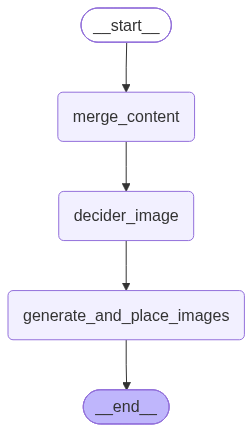

In [240]:
reducer_graph = StateGraph(AgentState)
reducer_graph.add_node("merge_content",merge_content)
reducer_graph.add_node("decider_image",decider_image)
reducer_graph.add_node("generate_and_place_images",generate_and_place_images)
reducer_graph.add_edge(START,"merge_content")
reducer_graph.add_edge("merge_content","decider_image")
reducer_graph.add_edge("decider_image","generate_and_place_images")
reducer_graph.add_edge("generate_and_place_images",END)
reducer_sub_graph = reducer_graph.compile()
reducer_sub_graph

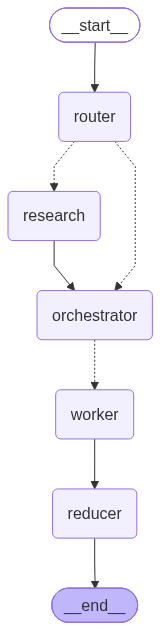

In [241]:
graph = StateGraph(AgentState)
graph.add_node('router',router_node)
graph.add_node('research',research_node)
graph.add_node('orchestrator',orchestrator)
graph.add_node('worker',worker)
graph.add_node('reducer',reducer_sub_graph)
graph.add_edge(START,'router')
graph.add_conditional_edges('router',route_next,{"research":"research","orchestrator":"orchestrator"})
graph.add_edge('research','orchestrator')

graph.add_conditional_edges("orchestrator",fanout,["worker"])
graph.add_edge("worker","reducer")
graph.add_edge('reducer',END)
workflow = graph.compile()
workflow

In [242]:
def run(topic : str,as_of : Optional[str]=None):
    if as_of is None:
        as_of = date.today().isoformat()
    out = workflow.invoke({
        'topic' : topic,
        'mode' : "",
        "needs_research" : False,
        "queries" : [],
        "evidence" : [],
        "plan" : None,
        "as_of":as_of,
        "recenty_days" : 7,
        "sections" : [],
        "merged_md":"",
        "md_with_placeholders":"",
        "final" : ""
    })
    return out

In [243]:
run('How AI Agents Are Changing Software Development in 2026')

[{'placeholder': '[[IMAGE_1]]', 'filename': 'ai_agent_workflow_2026.png', 'alt': 'Diagram showing software developer orchestrating AI agent swarms for coding and testing.', 'caption': 'Figure 1: The 2026 software development lifecycle, shifting human roles toward orchestration.', 'prompt': 'A clean technical architecture diagram showing a human software architect orchestrating three specialized AI agents labeled Code Generation, Automated Testing, and Refactoring. Minimalist vector style, dark theme, professional tech presentation graphic.', 'size': '1536x1024', 'quality': 'high'}, {'placeholder': '[[IMAGE_2]]', 'filename': 'multi_agent_swarm.png', 'alt': 'Flowchart of distributed multi-agent swarm handling bug fixes and integration tests.', 'caption': 'Figure 2: Autonomous multi-agent swarms executing parallel tasks in distributed repositories.', 'prompt': 'A system architecture flowchart illustrating a multi-agent swarm interacting with a central code repository, handling pull reques

{'topic': 'How AI Agents Are Changing Software Development in 2026',
 'mode': 'open_book',
 'as_of': '2026-08-28',
 'recenty_days': 7,
 'needs_research': True,
 'queries': ['AI agents software development 2026 trends',
  'autonomous coding agents state of the art 2026',
  'impact of AI agents on software engineering workflows 2026'],
 'evidence': [EvidenceItem(title='AI Agents in Software Development: A 2026 CTO Guide - Growin', url='https://www.growin.com/blog/ai-agents-in-software-development-26', published_at=None, snippet='AI agents in software development work differently. They receive a goal, decompose it into tasks, call the tools they need, run those tasks in parallel, and return a result.', source=None),
  EvidenceItem(title="What's Next in AI: Five Trends to Watch in 2026", url='https://blog.bytebytego.com/p/whats-next-in-ai-five-trends-to-watch', published_at=None, snippet='The baseline for coding agents is no longer just writing code. It is managing software at scale.', sou